# Projet Morpion

In [2]:
# Importation de notre classe Morpion depuis le fichier morpion.py
# Cette classe contient l'implémentation du jeu de base
from morpion import Morpion

# Matplotlib : bibliothèque de visualisation pour créer des graphiques
# Nous l'utiliserons pour visualiser l'apprentissage de l'IA
import matplotlib.pyplot as plt

# NumPy : bibliothèque pour le calcul scientifique
# Utilisée pour les opérations mathématiques et la manipulation de tableaux
import numpy as np

# Module random pour générer des nombres aléatoires
# Utilisé pour l'exploration dans l'algorithme de Q-Learning
import random

# IPython.display : module pour contrôler l'affichage dans Jupyter
# clear_output permet d'effacer la sortie précédente pour une meilleure visualisation
from IPython.display import clear_output

In [3]:
from morpion import Morpion

# Création d'une nouvelle instance du jeu
game = Morpion()

# L'IA (joueur 1) joue en position 1 (case en haut à gauche)
game.jouer_coup(1, 1)  # Placera un 'O'

# Le joueur humain (joueur 2) joue en position 2 (case en haut au milieu)
game.jouer_coup(2, 2)  # Placera un 'X'

# Affichage de l'état actuel du plateau
game.afficher_plateau()

|     |     
  O  |  X  |  3
_____|_____|_____
     |     |     
  4  |  5  |  6
_____|_____|_____
     |     |     
  7  |  8  |  9
     |     |

In [17]:
import numpy as np

def choisir_coup(coups_possibles, etat_actuel, etats_et_valeurs, epsilon=0.5):
    """
    Sélectionne le prochain coup en utilisant la stratégie epsilon-greedy du Q-Learning.
    Arguments:
    -----------
    coups_possibles : list
        Liste des coups qui peuvent être joués
    etat_actuel : list
        Vecteur représentant l'état actuel du jeu
    etats_et_valeurs : dict
        Dictionnaire contenant les valeurs associées à chaque état déjà rencontré
    epsilon : float, optionnel (défaut=0.1)
        Probabilité d'explorer (choisir un coup aléatoire)
    Retourne:
    -----------
    action : int
        Le coup choisi à jouer
    """
    exploitation = np.random.choice([0, 1], p=[epsilon, 1 - epsilon])
    if exploitation == 0:
        # EXPLORATION : Choisir un coup au hasard
        action = np.random.choice(coups_possibles)
    else:
        # EXPLOITATION : Choisir le coup avec la meilleure valeur
        meilleure_valeur = -999
        action = coups_possibles[0]  # Valeur par défaut
        for coup in coups_possibles:
            etat_test = etat_actuel.copy()
            etat_test.append(coup)
            valeur = etats_et_valeurs.get(tuple(etat_test), 0)
            if valeur > meilleure_valeur:
                meilleure_valeur = valeur
                action = coup
    return action

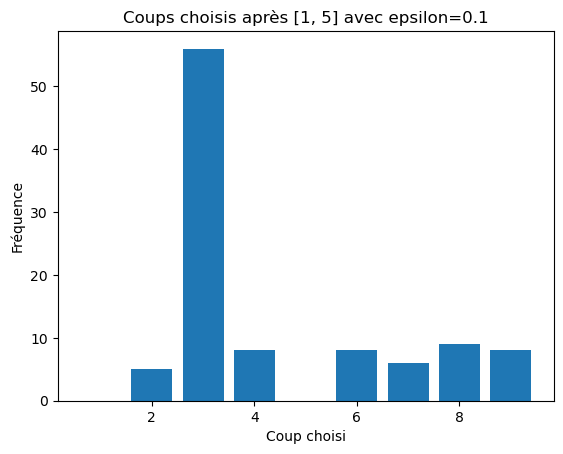

In [18]:
# Dictionnaire d'états et leurs valeurs associées
etats_et_valeurs = {
    (1,): 0.1,          # État après le coup 1
    (1, 5, 9): 0.02,   # État après les coups 1, 5, puis 9
    (1, 5, 3): 0.4,    # État après les coups 1, 5, puis 3
    (2,): 0.1,          # État après le coup 2
    (2, 3, 1): 0.2,    # État après les coups 2, 3, puis 1
    (2, 3, 5): 0.5     # État après les coups 2, 3, puis 5
}

# Situation hypothétique : les coups 1 et 5 ont été joués
etat_actuel = [1, 5]
coups_possibles = [2, 3, 4, 6, 7, 8, 9]

# Simuler 100 choix de coups pour voir la distribution
coups_choisis = []
for _ in range(100):
    coup = choisir_coup(coups_possibles, etat_actuel, etats_et_valeurs, epsilon=0.5)
    coups_choisis.append(coup)

# Visualisation avec un histogramme
import matplotlib.pyplot as plt

plt.hist(coups_choisis, bins=range(1, 11), align='left', rwidth=0.8)
plt.title('Coups choisis après [1, 5] avec epsilon=0.1')
plt.xlabel('Coup choisi')
plt.ylabel('Fréquence')
plt.show()

In [19]:
def attribuer_recompense(etats_et_valeurs, etats, recompense, taux_apprentissage=0.5, facteur_reduction=0.9):
    """
    Met à jour les valeurs associées à chaque état en fonction de la récompense obtenue.
    Arguments:
    -----------
    etats_et_valeurs : dict
        Dictionnaire stockant les valeurs de chaque état rencontré.
    etats : list
        Liste des états traversés pendant la partie (chaque état est une séquence de coups).
    recompense : float
        Récompense finale (1 pour victoire, -1 pour défaite, 0.5 pour nul).
    taux_apprentissage : float, optionnel (défaut=0.5)
        Alpha (α) : Vitesse d'apprentissage.
    facteur_reduction : float, optionnel (défaut=0.9)
        Gamma (γ) : Importance des récompenses éloignées.
    Retourne:
    -----------
    dict
        Dictionnaire mis à jour avec les nouvelles valeurs.
    """
    for etat in reversed(etats):
        etat_tuple = tuple(etat)
        if etat_tuple in etats_et_valeurs:
            etats_et_valeurs[etat_tuple] += taux_apprentissage * (
                facteur_reduction * recompense - etats_et_valeurs[etat_tuple]
            )
        elif etat != etats[-1]:
            etats_et_valeurs[etat_tuple] = taux_apprentissage * facteur_reduction * recompense
        else:
            etats_et_valeurs[etat_tuple] = recompense
        recompense = etats_et_valeurs[etat_tuple]
    return etats_et_valeurs

In [22]:
etats_et_valeurs = {
    (1,): 0.0,
    (1, 5): 0.0,
    (1, 5, 3): 0.0,
    (1, 5, 3, 7): 0.0
}
recompense_finale = -1.0  # Défaite

print("Valeurs avant mise à jour :")
for etat, valeur in etats_et_valeurs.items():
    print(f"État {list(etat)} : {valeur:.3f}")

nouvelles_valeurs = attribuer_recompense(
    etats_et_valeurs, etats, recompense_finale, taux_apprentissage=0.5, facteur_reduction=0.9
)

print("\nValeurs après mise à jour :")
for etat, valeur in nouvelles_valeurs.items():
    print(f"État {list(etat)} : {valeur:.3f}")

Valeurs avant mise à jour :
État [1] : 0.000
État [1, 5] : 0.000
État [1, 5, 3] : 0.000
État [1, 5, 3, 7] : 0.000

Valeurs après mise à jour :
État [1] : -0.041
État [1, 5] : -0.091
État [1, 5, 3] : -0.203
État [1, 5, 3, 7] : -0.450
État [1, 5, 3, 7, 2] : -1.000


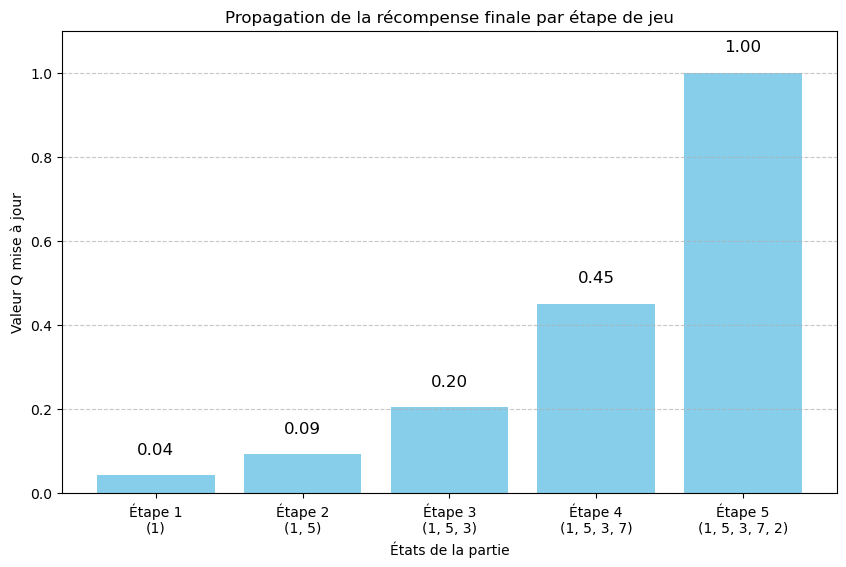

In [21]:
import matplotlib.pyplot as plt

# Préparation des données pour le graphique
labels = [f"Étape {i+1}\n({', '.join(map(str, etat))})" for i, etat in enumerate(etats)]
valeurs_a_tracer = [nouvelles_valeurs[tuple(etat)] for etat in etats]

# Création du graphique
plt.figure(figsize=(10, 6))
plt.bar(labels, valeurs_a_tracer, color='skyblue')
plt.xlabel("États de la partie")
plt.ylabel("Valeur Q mise à jour")
plt.title("Propagation de la récompense finale par étape de jeu")
plt.ylim(0, 1.1)
for i, v in enumerate(valeurs_a_tracer):
    plt.text(i, v + 0.05, f"{v:.2f}", ha='center', color='black', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()